# 17. Evaluate clustering goodness-of-fit by scDesigner

This notebook demonstrates scDesigner's ability to evaluate clustering goodness-of-fit for cell type assignments. Ideally, more accurate clustering assignments leads to better simulation results. Therefore, for datasets that don't have ground-truth labels, we can use scDesigner's Bayesian Information Criterion (BIC) as an unsupervised metric to assist clustering evaluation:

$$
\mathrm{BIC} = -2 \log \hat{L} + p \log n,
$$

where $\hat{L}$ is the maximized likelihood, $p$ is the number of estimated model parameters, and $n$ is the number of cell, with smaller BIC indicating better model fit. 

The data we use comes from the [Zhengmix4](https://www.nature.com/articles/ncomms14049) dataset, which sequenced human PBMC data under 10x scRNA-seq protocol and contains 3555 cells with 1556 genes.

In [1]:
from scdesigner.datasets import zhengmix4

example_sce = zhengmix4()
example_sce

AnnData object with n_obs × n_vars = 3555 × 1556
    obs: 'dataset', 'barcode', 'phenoid', 'libsize.drop', 'feature.drop', 'total_features', 'log10_total_features', 'total_counts', 'log10_total_counts', 'pct_counts_top_50_features', 'pct_counts_top_100_features', 'pct_counts_top_200_features', 'pct_counts_top_500_features', 'is_cell_control', 'sizeFactor', 'trueclass', 'cluster_2', 'cluster_3', 'cluster_4', 'cluster_5', 'cluster_6', 'cluster_7', 'cluster_8', 'cluster_9', 'cluster_10'
    var: 'id', 'symbol', 'is_feature_control', 'mean_counts', 'log10_mean_counts', 'rank_counts', 'n_cells_counts', 'pct_dropout_counts', 'total_counts', 'log10_total_counts'
    uns: 'X_name', 'log.exprs.offset'
    obsm: 'PCA', 'TSNE'
    layers: 'logcounts', 'normcounts'

The `Zhengmix4` dataset contains cell type information, which we will treat as the ground-truth clusters and save in `trueclass` column of the `.obs` dataframe of our anndata object. Additionally, the [DuoClustering2018](https://github.com/csoneson/DuoClustering2018) package in R provides k-means clustering assignments of the `Zhengmix4` dataset based on k = 2, ..., 10, which we store as `cluster_{k}` columns in `.obs`.

In [2]:
example_sce.obs['trueclass'].head()

b.cells6276    b.cells
b.cells6144    b.cells
b.cells6285    b.cells
b.cells8679    b.cells
b.cells96      b.cells
Name: trueclass, dtype: category
Categories (4, object): ['b.cells', 'cd14.monocytes', 'naive.cytotoxic', 'regulatory.t']

For each cell-type clustering information based on k, we will fit using `NegBinCopula` simulator and use the `cluster_{k}` covariate to model the mean and dispersion. We will record both the model's marginal BIC and the Adjusted Rand Index (ARI) scores, where the ARI scores measure the similarity between the k-means clustering and the ground-truth labels, with larger ARI indicating better clustering assignments. 

The marginal BIC score is stored in `simulator.complexity()`, where we also have the marginal AIC and copula AIC, BIC information saved.

For simplicity, we will select the top 100 highly variable genes for model fitting.

In [3]:
from scdesigner.simulators import NegBinCopula
from sklearn.metrics import adjusted_rand_score
import numpy as np
import pandas as pd
import scanpy as sc

ngene = 100
sc.pp.highly_variable_genes(
    example_sce,
    n_top_genes=ngene,
)

np.random.seed(123)

rows = []
for k in range(2, 11):
    cluster_key = f"cluster_{k}"
    sce = example_sce[:, example_sce.var["highly_variable"]].copy()
    sce.obs["cell_type"] = sce.obs[cluster_key].astype("category")

    sim = NegBinCopula(
        mean_formula="~ cell_type",
        dispersion_formula="~ cell_type",
        copula_formula="~ 1",
    )
    sim.fit(sce)
    metrics = sim.complexity()

    ari = adjusted_rand_score(sce.obs["cell_type"], sce.obs["trueclass"])

    rows.append(
        {
            "bic_marginal": metrics["marginal_bic"],
            "bic_copula": metrics["copula_bic"],
            "bic_total": metrics["marginal_bic"] + metrics["copula_bic"],
            "ari": ari,
        }
    )

metric = pd.DataFrame(rows)
metric

Epoch 338/500, Loss: 1.0579, Val Loss: 1.0692


Computing log-likelihood...: 100%|██████████| 4/4 [00:00<00:00, 141.23it/s]


Epoch 352/500, Loss: 1.0194, Val Loss: 1.0299


Computing log-likelihood...: 100%|██████████| 4/4 [00:00<00:00, 180.03it/s]


Epoch 341/500, Loss: 1.0190, Val Loss: 1.0295


...

Epoch 224/500, Loss: 1.0047, Val Loss: 1.0163


Computing log-likelihood...: 100%|██████████| 4/4 [00:00<00:00, 191.21it/s]


Epoch 194/500, Loss: 0.9999, Val Loss: 1.0100


Computing log-likelihood...: 100%|██████████| 4/4 [00:00<00:00, 196.03it/s]


,bic_marginal,bic_copula,bic_total,ari
0,756287.381637,-15844.122413,740443.259224,-0.000123
1,730510.416205,-688.037376,729822.378830,0.286708
2,731862.450774,-784.806718,731077.644056,0.283281
3,731111.922842,-624.112578,730487.810265,0.256913
4,724084.582411,2627.653062,726712.235472,0.516503
5,728826.366979,1434.081550,730260.448530,0.357729
6,729029.401548,1997.098965,731026.500513,0.351157
7,729926.186116,1870.274205,731796.460321,0.370254
8,728093.845684,1760.246890,729854.092575,0.438566


The figure below suggests that the model's BIC is able to identify the best choice of K according to ARI.

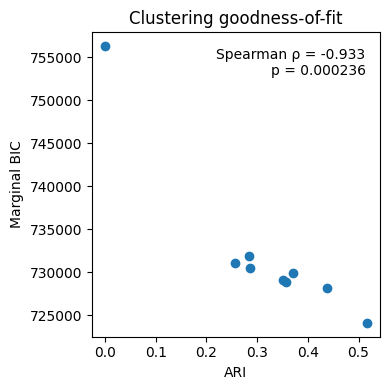

In [4]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

rho, pvalue = spearmanr(metric["ari"], metric["bic_marginal"])

fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(metric["ari"], metric["bic_marginal"])

ax.text(
    0.95, 0.95,
    f"Spearman ρ = {rho:.3f}\np = {pvalue:.3g}",
    transform=ax.transAxes,
    ha="right", va="top",
)

ax.set_xlabel("ARI")
ax.set_ylabel("Marginal BIC")
ax.set_title("Clustering goodness-of-fit")
fig.tight_layout()
plt.show()